# Working on Retail Sales Dataset to find meaningful insights and give recommendation for betterment.

## 1. Data Loading and Cleaning: Load the retail sales dataset.

In [65]:
# Importing Specific library which are required for data pre-processing tasks.

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [66]:
# Loading the dataset and checking the first 5 rows of the dataset.

df = pd.read_csv('retail_sales_dataset.csv')
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [83]:
# Making a copy of the dataset to perform data pre-processing tasks.

df_copy = df.copy()

In [68]:
# Checking the shape, non-null values, and Statistical summary( for numerical data) of the dataset.

print("Shape of the dataset:", df_copy.shape)
print("\nNon-null values in the dataset:\n", df_copy.info())
print("\nStatistical summary of the dataset:\n", df_copy.describe())

Shape of the dataset: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Non-null values in the dataset:
 None

Statistical summary of the dataset:
        Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.00000

- We observe that the dataset contains 1000 rows and 9 columns. The columns include 'Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', and 'Total Amount'. With data types like 'int' and 'object'.
- Also there are no null values in the dataset, which is a good sign for data quality. The statistical summary of the numerical columns shows that the average age of customers is around 35 years, with a minimum age of 18 and a maximum age of 64. The average quantity of products purchased is around 3, with a minimum of 1 and a maximum of 10. The average price per unit is around 179, with a minimum of 25 and a maximum of 500. The average total amount spent by customers is around 456, with a minimum of 25 and a maximum of 2000.

In [84]:
# Changing the date column to datetime format for better analysis.

df_copy['Date'] = pd.to_datetime(df_copy['Date'])
df_copy['Month'] = df_copy['Date'].dt.month
df_copy['Year'] = df_copy['Date'].dt.year

In [69]:
# Checking the missing values in the dataset.

missing_values = df_copy.isnull().sum()
print("\nMissing values in the dataset:\n", missing_values)


Missing values in the dataset:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## 2. Descriptive Statistics: Calculate basic statistics (mean, median, mode, standard deviation).

In [85]:
# Calculating the Descriptive Statistics for numerical columns in the dataset.

numerical_cls = df_copy.select_dtypes(include=[np.number]).drop(columns=['Transaction ID'])
print("\nMean of numerical columns:\n", numerical_cls.mean())
print("\nMedian of numerical columns:\n", numerical_cls.median())
print("\nMode of numerical columns:\n", numerical_cls.mode().iloc[0])
print("\nStandard Deviation of numerical columns:\n", numerical_cls.std())



Mean of numerical columns:
 Age                 41.392
Quantity             2.514
Price per Unit     179.890
Total Amount       456.000
Month                6.549
Year              2023.002
dtype: float64

Median of numerical columns:
 Age                 42.0
Quantity             3.0
Price per Unit      50.0
Total Amount       135.0
Month                6.0
Year              2023.0
dtype: float64

Mode of numerical columns:
 Age                 43.0
Quantity             4.0
Price per Unit      50.0
Total Amount        50.0
Month                5.0
Year              2023.0
Name: 0, dtype: float64

Standard Deviation of numerical columns:
 Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
Month               3.452755
Year                0.044699
dtype: float64


In [71]:
# Listing different unique values for nominal columns of the dataset.

print("Unique product categories:", df_copy['Product Category'].unique())

Unique product categories: ['Beauty' 'Clothing' 'Electronics']


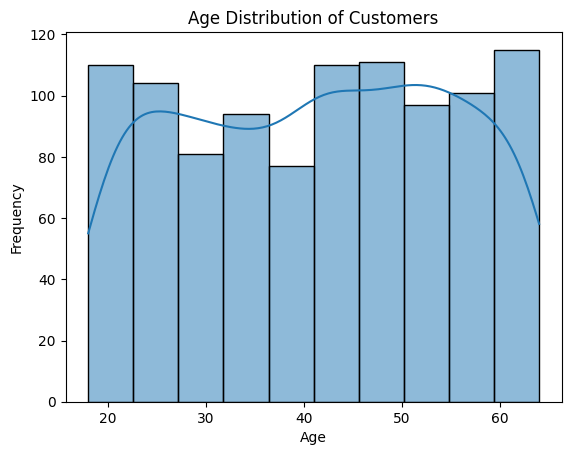

None

In [72]:
# For the retail sales dataset, the distribution of Uni, Bi, and Multi-Variate analysis can be visualized using various plots.

# For Univariate analysis, we can use histograms or box plots to visualize the distribution of numerical columns like 'Age', 'Quantity', 'Price per Unit', and 'Total Amount'. For example, a histogram of the 'Age' column can show us the age distribution of customers.

sns.histplot(df_copy['Age'], bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
display(plt.show())

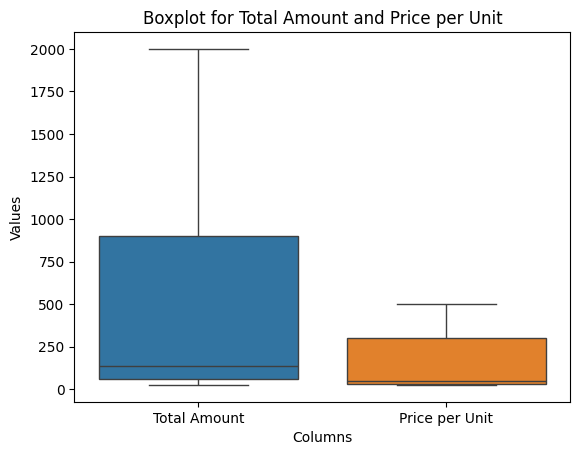

In [73]:
# Checking the boxplot for the dataset columns to identify the outliers in the dataset.

sns.boxplot(data=df_copy[['Total Amount', 'Price per Unit']])
plt.title('Boxplot for Total Amount and Price per Unit')
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

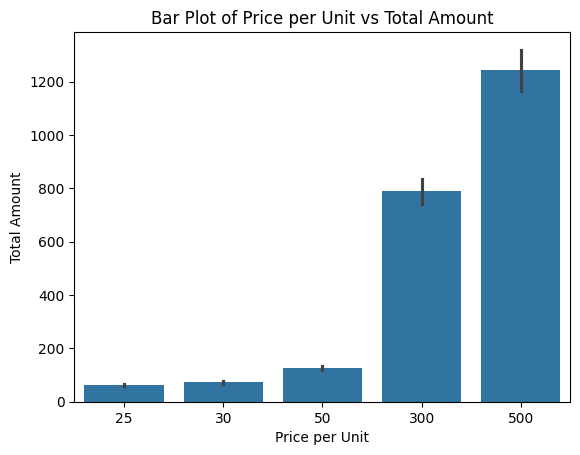

In [74]:
# Bivariate analysis can be performed using scatter plots or bar plots to visualize the relationship between two numerical columns or a numerical and a categorical column. For example, a scatter plot of 'Price per Unit' vs 'Total Amount' can show us if there is any correlation between the price and the total amount spent by customers.

sns.barplot(x='Price per Unit', y='Total Amount', data=df_copy, )
plt.title('Bar Plot of Price per Unit vs Total Amount')
plt.xlabel('Price per Unit')
plt.ylabel('Total Amount')
plt.show()

- As we can see from the barplot of the Total Amount vs price per unit there is a positive correlation between the price per unit and the total amount spent by customers. This indicates that as the price per unit increases, the total amount spent by customers also tends to increase. This could be because customers are purchasing more expensive products or buying in larger quantities when the price per unit is higher. It is important for retailers to consider this relationship when setting prices and offering promotions to maximize revenue.

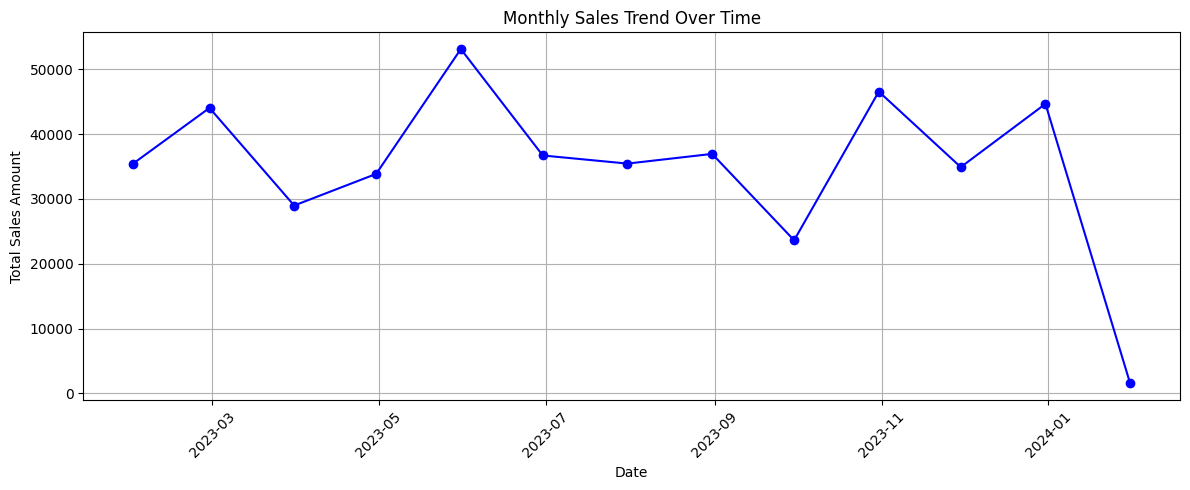

In [75]:
# Convert Date to datetime and set as index
df_copy['Date'] = pd.to_datetime(df_copy['Date'])
df_copy.set_index('Date', inplace=True)

# Resample by month and sum Total Amount
monthly_sales = df_copy.resample('ME')['Total Amount'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='b')
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

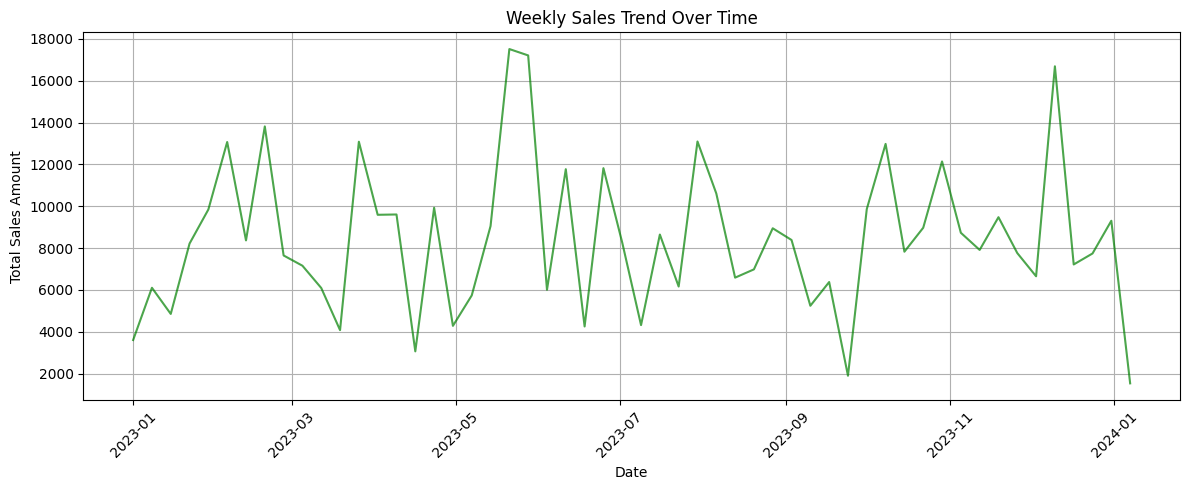

In [76]:
# Weekly sales trend
weekly_sales = df_copy.resample('W')['Total Amount'].sum()

plt.figure(figsize=(12, 5))
plt.plot(weekly_sales.index, weekly_sales.values, color='green', alpha=0.7)
plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Customer and Product Analysis

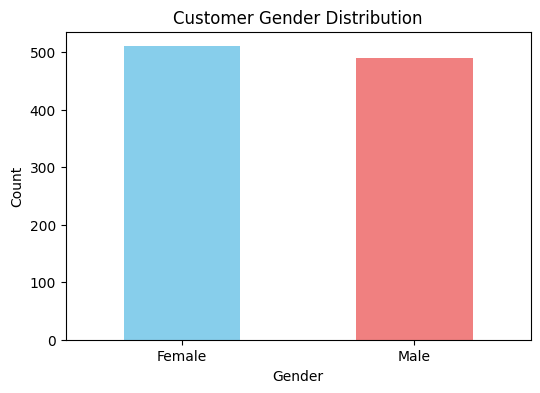

Gender
Female    510
Male      490
Name: count, dtype: int64


In [77]:
# Customer Demographics: Gender distribution
gender_counts = df_copy['Gender'].value_counts()

plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
print(gender_counts)

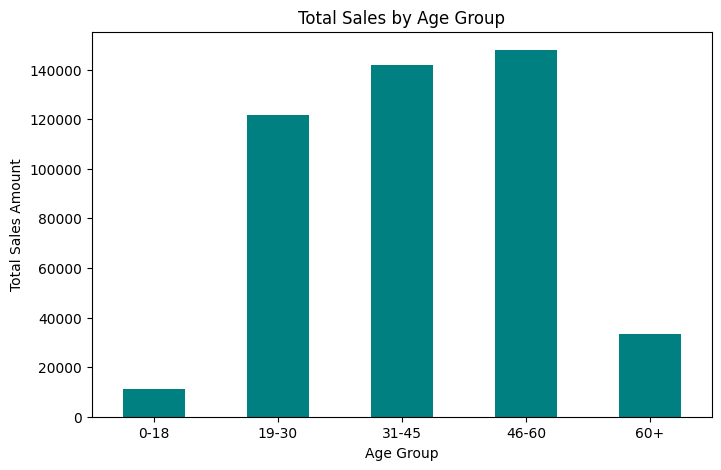

In [78]:
# Age group analysis
df_copy['Age Group'] = pd.cut(df_copy['Age'], bins=[0, 18, 30, 45, 60, 100],
                              labels=['0-18', '19-30', '31-45', '46-60', '60+'])

age_group_sales = df_copy.groupby('Age Group', observed=False)['Total Amount'].sum()

plt.figure(figsize=(8, 5))
age_group_sales.plot(kind='bar', color='teal')
plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=0)
plt.show()

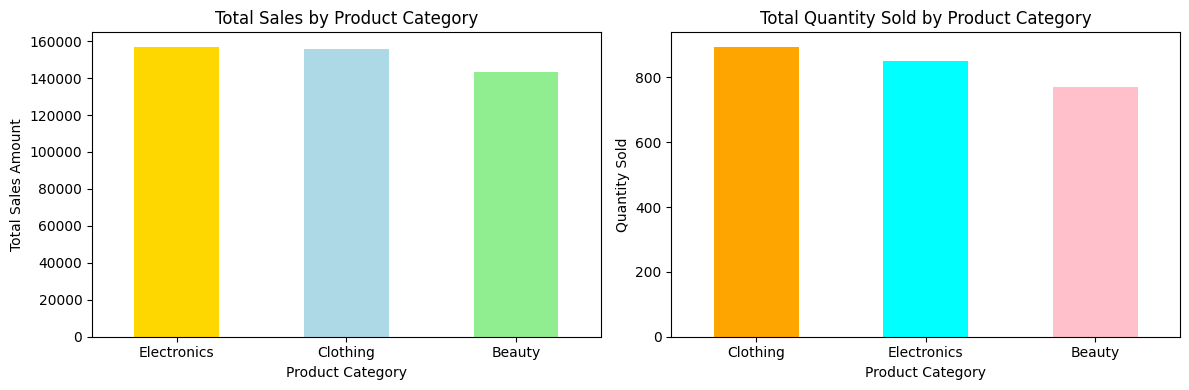

Sales by Category:
 Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64
Quantity by Category:
 Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [79]:
# Product Category analysis
category_sales = df_copy.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_qty = df_copy.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

category_sales.plot(kind='bar', ax=axes[0], color=['gold', 'lightblue', 'lightgreen'])
axes[0].set_title('Total Sales by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Sales Amount')
axes[0].tick_params(axis='x', rotation=0)

category_qty.plot(kind='bar', ax=axes[1], color=['orange', 'cyan', 'pink'])
axes[1].set_title('Total Quantity Sold by Product Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Quantity Sold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('Sales by Category:\n', category_sales)
print('Quantity by Category:\n', category_qty)

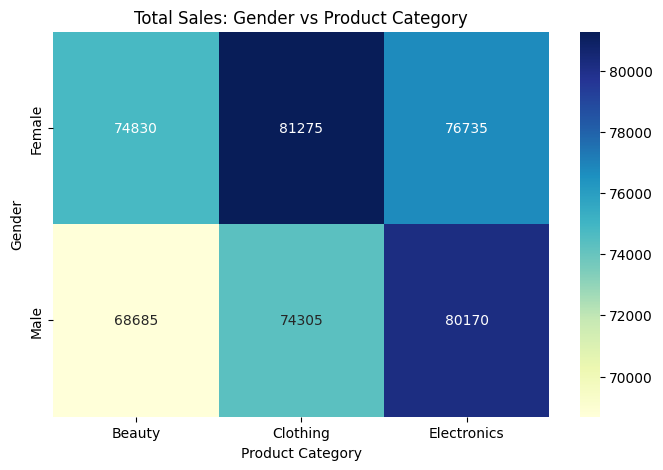

In [80]:
# Gender vs Product Category heatmap (cross-tabulation)
cross_tab = pd.crosstab(df_copy['Gender'], df_copy['Product Category'], values=df_copy['Total Amount'], aggfunc='sum')

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Total Sales: Gender vs Product Category')
plt.show()

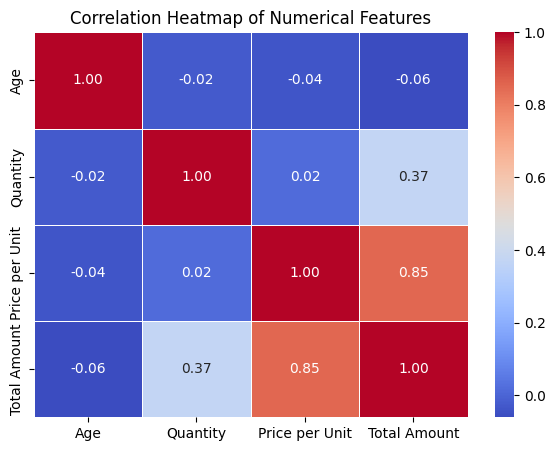

In [82]:
# Correlation heatmap for numerical features
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr_matrix = df_copy[numerical_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.6)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 6. Recommendations

Based on the EDA, here are actionable recommendations:

1. **Inventory Management**: Focus stock on top-selling product categories (Clothing and Electronics appear high-value). Ensure sufficient stock of high-quantity items.

2. **Targeted Marketing**: The 31-45 and 46-60 age groups generate the most sales. Design targeted promotions and loyalty programs for these demographics.

3. **Gender-Based Campaigns**: Use the gender vs category heatmap to create gender-specific marketing. For categories where one gender dominates, tailor advertising accordingly.

4. **Pricing Strategy**: With Price per Unit having high variance, consider bundling lower-priced items or offering volume discounts to increase average transaction value.

5. **Seasonal Promotions**: Use the monthly sales trend to identify peak months and plan promotions or clearance sales during slower periods.

6. **Customer Retention**: Implement a loyalty program targeting the most profitable age groups to encourage repeat purchases.